In [2]:
import sys
sys.path.append("../src")
import numpy as np
import matplotlib.pyplot as plt
from baseline import run_baseline, load_processed
from config import FIG_DIR

In [3]:
model, vec, metrics = run_baseline()
metrics

Loading data...
Vectorizing 339,499 jokes (TF-IDF, this is the slow step)...
  done in 45s | matrix (339499, 304036)
Fitting Ridge regression...
  done in 18s

Test metrics
Spearman rho: 0.3630   <- headline number
Pearson r:    0.4136
MAE:          1.2457
RMSE:         1.6447

(predict-the-mean RMSE 1.7960 — model should be lower)


{'spearman': np.float64(0.3630353747698284),
 'pearson': np.float64(0.4136033588872281),
 'mae': 1.2456600032576826,
 'rmse': 1.644666293182166}

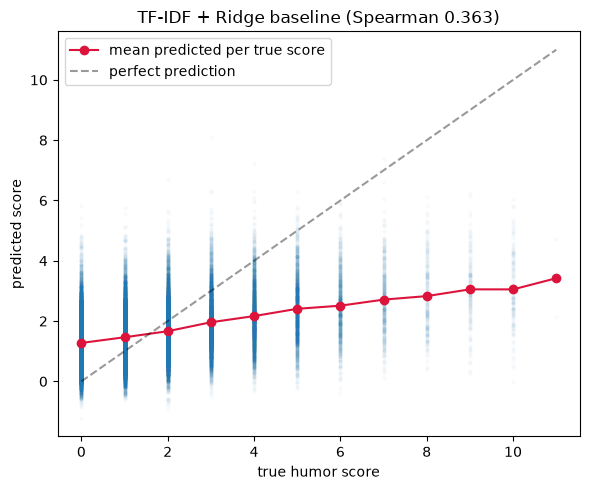

In [4]:
# predicted vs actual
test = load_processed("test")
pred = model.predict(vec.transform(test["joke"]))

# average predicted score within each true score bucket (0-11)
import pandas as pd
df = pd.DataFrame({"true": test["score"], "pred": pred})
means = df.groupby("true")["pred"].mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df["true"], df["pred"], alpha=0.02, s=5)
ax.plot(means.index, means.values, "o-", color="crimson",
        label="mean predicted per true score")
ax.plot([0, 11], [0, 11], "k--", alpha=0.4, label="perfect prediction")
ax.set_xlabel("true humor score")
ax.set_ylabel("predicted score")
ax.set_title(f"TF-IDF + Ridge baseline (Spearman {metrics['spearman']:.3f})")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "03_baseline_pred_vs_true.png", dpi=150, bbox_inches="tight")
plt.show()